<a href="https://colab.research.google.com/github/gpicciuca/ai_engineering_master/blob/main/module6_deeplearning/Progetto_Riconoscimento_di_animali_per_auto_a_guida_autonoma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Riconoscimento di animali per auto a guida autonoma
Modulo: Deep Learning e Reti Neurali Artificiali <br>
Corso: Master in AI Engineering @ Profession.AI


In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Conv2D, MaxPooling2D, Flatten, GlobalAveragePooling2D
from tensorflow.keras.losses import categorical_crossentropy, sparse_categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.backend import clear_session
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt
import PIL
import numpy as np

# Helper/Utility methods
Metodi riutilizzabili per tenere il codice più pulito e semplice da gestire.

In [ ]:
def show_image(image_buffer, image_label):
    """
    Visualizza una singola immagine.

    Args:
        image_buffer: Buffer dell'immagine.
        image_label: Etichetta dell'immagine.
    """
    img = PIL.Image.fromarray(image_buffer)
    plt.figure(figsize=(2, 2))
    plt.imshow(img)
    plt.tight_layout()
    plt.axis('off')
    plt.title(image_label)
    plt.show()

# Esplorazione del dataset
Analizziamo il dataset CIFAR10 che contiene 10 classi diverse.

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Dizionario con le key-value del dataset, prese dalla documentazione
cifar10_id2label = {
  0: "airplane",
  1: "automobile",
  2: "bird",
  3: "cat",
  4: "deer",
  5: "dog",
  6: "frog",
  7: "horse",
  8: "ship",
  9: "truck"
}

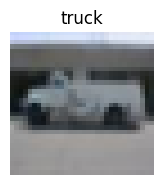

In [ ]:
show_image(x_train[110], cifar10_id2label[y_train[110][0]])

# Preparazione del dataset
La consegna chiede di distinguere tra animali e veicoli. Il dataset contiene diverse tipologie di animali così come di veicoli. Per semplificare il processo di classificazione, si può procedere col raggruppare le label così da dover gestire solo 2 classi anzichè 10: veicoli e animali

In [ ]:
# Dict contenente le 2 classi raggruppate
remapped_id2label = {0: "vehicle", 1: "animal"}
remapped_label2id = {"vehicle": 0, "animal": 1}

# Normalizziamo il train e test set così da portare i byte nel range 0.0 - 1.0
# Servirà per la fase di training ed inferenza
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

# Sostituiamo le label con quelle rimappate
# Le classi 0, 1, 8, 9 (vedi cifar10_id2label) vengono sostituite con la classe 0 (vehicle)
# mentre le classi restanti con la classe 1 (animal)
y_train_mapped = np.asarray([0 if i in [0, 1, 8, 9] else 1 for i in y_train])
y_test_mapped = np.asarray([0 if i in [0, 1, 8, 9] else 1 for i in y_test])

Verifichiamo che il remapping è stato effettuato correttamente:

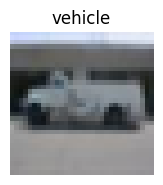

In [ ]:
show_image(x_train[110], remapped_id2label[y_train_mapped[110]])

# La label originale era "truck". Ora dovrebbe essere "vehicle":

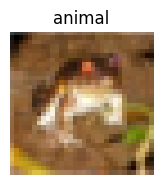

In [ ]:
show_image(x_train[0], remapped_id2label[y_train_mapped[0]])

# La label originale era "frog". Ora dovrebbe essere "animal":

# Creazione del modello
Procediamo con la creazione di un architettura semplice basata su alcuni layer di convoluzione e densi. <br>
La rete riceverà in input un'immagine di 32x32 pixel con 3 canali (RGB), quindi avrà shape (32, 32, 3). <br>
In output riceveremo un vettore di 2 elementi (classi) con funzione di attivazione softmax. Quindi sarà un vettore di probabilità e la posizione all'interno di tale vettore indica la classe di riferimento.

In [ ]:
clear_session()

model = Sequential([
    # Layer di input per l'immagine RGB da 32x32 px
    Input(shape=(32, 32, 3)),

    # Layer di convoluzione a 256 filtri di dimensione 4x4
    # In genere il primo layer cattura le feature di basso livello come bordi, spigoli, contorni, ecc
    # Stride (1, 1) farà slittare il filtro sull'immagine 1px alla volta
    Conv2D(256, kernel_size=(4, 4), strides=(1, 1), activation="relu", padding="same"),
    # Il risultato della convoluzione verrà compresso per un fattore di 2x2 andando ad eliminare
    # informazioni dall'immagine che i filtri non hanno catturato.
    MaxPooling2D(pool_size=(2, 2)), # Riduce l'output da 32x32 -> 16x16
    # Normalizza l'output per mantenerlo nel range 0-1, favorendo la convergenza durante l'addestramento.
    BatchNormalization(),

    # Qui, l'input non sarà più 32x32 ma 16x16 per via della compressione del pooling.
    # Il stride contribuisce anch'esso alla compressione, ma solo se > 1

    # Layer di convoluzione a 512 filtri di dimensione 3x3 e stride 2x2
    # Il secondo layer di convoluzione riesce a catturare feature più ampie rispetto ai layer precedenti.
    # Se nei layer precedenti venivano captati gli angoli e i bordi, qui si riuscirà a captare
    # i contorni e le feature più grandi che caratterizzano l'immagine.
    Conv2D(512, kernel_size=(3, 3), strides=(2, 2), activation="relu", padding="same"),
    # Pooling dell'output della convoluzione. Il stride 2x2 ha già compresso l'immagine dimezzandone la dimensione.
    # Con il pooling di 2x2 verrà dimezzata ancora una volta.
    # Quindi se la 2. convoluzione ha ricevuto 16x16 in input, con stride 2x2 scende a 8x8
    # Con il pooling da 2x2 va da 8x8 a 4x4
    MaxPooling2D(pool_size=(2, 2)),
    # Normalizziamo l'output
    BatchNormalization(),

    # Terzo e ultimo layer di convoluzione a 1024 filtri di 2x2 e stride 1x1
    # Qui l'immagine avrà una dimensione pari a 4x4
    # La convoluzione dovrebbe riuscire, quanto più possibile data la dimensione 4x4, a catturare
    # le feature più di alto livello.
    Conv2D(1024, kernel_size=(2, 2), strides=(1, 1), activation="relu", padding="same"),
    # Normalizziamo l'output senza effettuare alcun pooling data la dimensione restante.
    BatchNormalization(),

    # Prende l'output del layer precedente e lo trasforma in un vettore 1D
    # Ad es. se l'input è (4, 4, 128), il flatten genera un vettore (X, 4*4*128) = (X, 2048)
    # N.B.: (Qui X sta per la batch size)
    Flatten(),

    # Layer densi fully-connected per la classificazione delle feature estratte dai
    # layer convoluzionali con Dropout del 20% per evitare overfitting
    Dense(1024, activation="relu"),
    Dropout(0.2),
    Dense(1024, activation="relu"),
    Dropout(0.2),

    # Layer finale di output con 2 classi. Restituisce un vettore di 2 elementi con le
    # probabilità di appartenenza alle varie classi.
    Dense(len(remapped_id2label.keys()), activation="softmax")
])

# LearningRate scheduler con decadimento esponenziale
# Ha lo scopo di ridurre la learning rate. La learning rate ha un impatto diretto sull'aggiornamento dei pesi
# durante la fase di addestramento. Un LR più alto amplia la modifica applicata ai pesi, possibilmente destabilizzando
# la convergenza. Riducendo il LR favorisce una convergenza più precisa, ma rallenta notevolmente il processo.
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=100,
    decay_rate=0.95)

# Compilazione del modello con una Sparse Categorical Crossentropy come loss function, un Stochastic Gradient Descent optimizer
# in cui impostiamo il momentum a 0.9. Ed infice specifichiamo le metriche da calcolare (qui solo l'accuracy).
# N.B.: Il momentum viene utilizzato internamente per ampliare o attenuare la velocità di aggiornamento dei pesi.
model.compile(
    loss = sparse_categorical_crossentropy,
    optimizer=tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9),
    metrics = ["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 256)         │          12,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 8, 8, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 4, 4, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 1024)          │       2,098,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 4, 4, 1024)          │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │      16,778,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1024)                │       1,049,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │           2,050 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,127,938 (80.60 MB)

 Trainable params: 21,124,354 (80.58 MB)

 Non-trainable params: 3,584 (14.00 KB)

# Addestramento del modello
Addestriamo il modello con l'architettura appena definita sul dataset preparato ad inizio del notebook. <br>
Il numero di epoche è impostato ad un valore abbastanza alto, ma il training si fermerà nonappena la "validation loss" raggiungere un punto in cui non migliorerà più. <br>
Al termine di ogni metrica verrà effettuata una validation sul testset per valutarne l'accuratezza.

In [ ]:
# Controlla la validation loss ad ogni epoca e se dopo 3 epoche la val_loss non è migliorata di almeno 0.001,
# termina l'addestramento.
early_stopping_cb = EarlyStopping(monitor="val_loss", patience=3, min_delta=0.001)

# Fit del modello
hist = model.fit(x_train_norm, y_train_mapped, epochs=50, batch_size=32, validation_data=(x_test_norm, y_test_mapped), callbacks=[early_stopping_cb])

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1622s 4s/step - accuracy: 0.8838 - loss: 0.2866 - val_accuracy: 0.9024 - val_loss: 0.2542
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1600s 4s/step - accuracy: 0.9180 - loss: 0.2067 - val_accuracy: 0.9174 - val_loss: 0.1970
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1580s 4s/step - accuracy: 0.9328 - loss: 0.1702 - val_accuracy: 0.9074 - val_loss: 0.2246
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1605s 4s/step - accuracy: 0.9413 - loss: 0.1489 - val_accuracy: 0.9168 - val_loss: 0.2038
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1622s 4s/step - accuracy: 0.9501 - loss: 0.1307 - val_accuracy: 0.9188 - val_loss: 0.2035


# Valutazione dell'addestramento
Verifichiamo l'andamento della loss/val_loss e accuracy/val_accuracy dell'addestramento per avere più chiaro l'andamento. <br>
Tale informazione la si vede già nell'output del metodo fit(), ma i grafici ne rendono la lettura molto più semplice ed immediata.

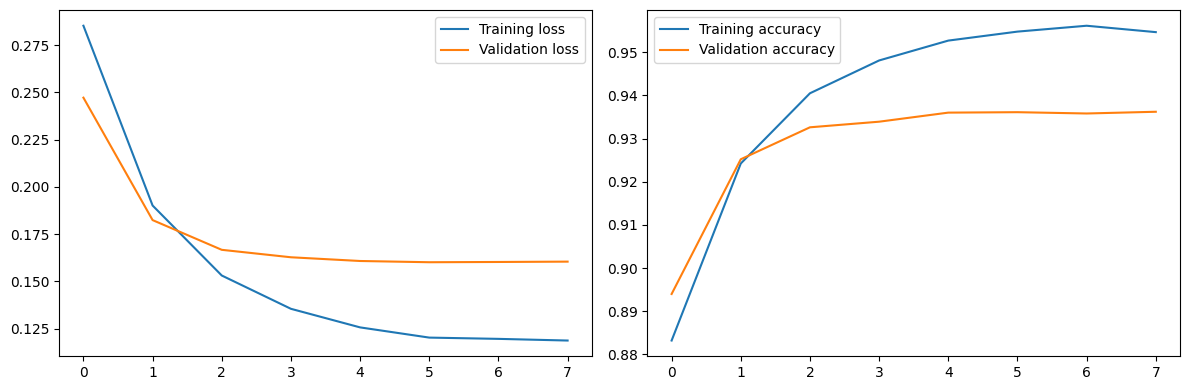

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(hist.history["loss"], label="Training loss")
plt.plot(hist.history["val_loss"], label="Validation loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist.history["accuracy"], label="Training accuracy")
plt.plot(hist.history["val_accuracy"], label="Validation accuracy")
plt.legend()

plt.tight_layout()
plt.show()

Dai grafici vediamo che l'addestramento è arrivato a convergenza parecchio in fretta, arrivando ad un ~0.936 per la validation accuracy (quindi accuracy sul testset) e quasi ~0.954 per la training accuracy (trainset). <br>
È decisamente un buon risultato poichè train e test hanno raggiunto performance più o meno uguali anche se il fatto dell'avere la training accuracy 2% più alta rispetto la validation può indicare un lieve grado di overfitting.

Verifichiamo nuovamente l'accuratezza mediante il metodo evaluate() sul testset:

In [ ]:
model.evaluate(x_test_norm, y_test_mapped, batch_size=32, return_dict=True)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9370 - loss: 0.1651


{'accuracy': 0.9362000226974487, 'loss': 0.16042868793010712}

Il quale ci conferma le metriche viste nell'output precedente. <br><br>
Analizziamo alcune metriche più nel dettaglio:

In [ ]:
y_pred = model.predict(x_test_norm, batch_size=32)
y_pred = np.argmax(y_pred, axis=1) # Estrae le classi predette per ogni esempio

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


Plottiamo la confusion matrix per verificare quanti esempi sono stati classificati correttamente e quanti no:

<Axes: >

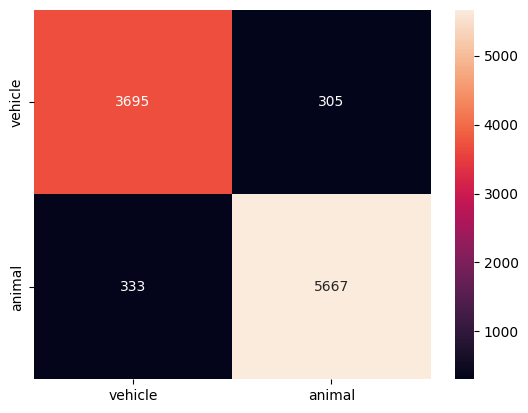

In [ ]:
sns.heatmap(confusion_matrix(y_test_mapped, y_pred), annot=True, fmt='g', xticklabels=remapped_id2label.values(), yticklabels=remapped_id2label.values())

In [ ]:
print(f"Precision: {precision_score(y_test_mapped, y_pred)}")
print(f"Recall: {recall_score(y_test_mapped, y_pred)}")

Precision: 0.9489283322170127
Recall: 0.9445


Dalla confusion matrix vediamo che il modello sbaglia la classificazione in maniera abbastanza equilibrata. <br><br>
Ha una precisione di quasi del 95%, il che indica che il modello è abbastanza "sicuro" nella classificazione. Mentre il recall del 94,5% indica che nel 5,5% dei casi riporta un bias per la classe errata.

# Analisi delle classificazioni errate
Verifichiamo quali immagini sono state classificate incorrettamente.

In [ ]:
y_true = y_pred == y_test_mapped
print(f"Corrette: {np.sum(y_true)}")
print(f"Sbagliate: {len(y_true) - np.sum(y_true)}")

Corrette: 9362
Sbagliate: 638


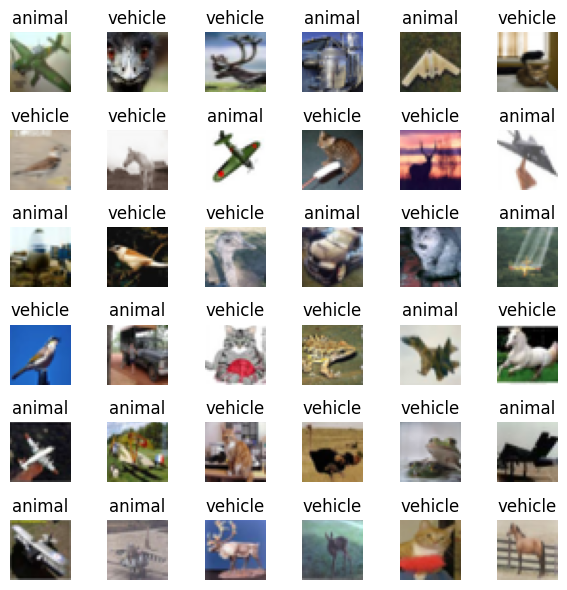

In [ ]:
x_test_err = x_test[~y_true]
y_test_err = y_pred[~y_true]

fig, axes = plt.subplots(6, 6, figsize=(6, 6))

for i in range(0, 36):
    img = PIL.Image.fromarray(x_test_err[i])

    ax = axes[i // 6, i % 6]
    ax.imshow(img)
    ax.set_title(remapped_id2label[y_test_err[i]])
    ax.axis('off')

plt.tight_layout()
plt.show()

Le immagini riportate nel plot non sembrano essere particolarmente difficili da classificare (almeno per l'occhio umano). Ciò nonostante la rete li ha classificati con la label opposta.

# Conclusione
Il modello addestrato presenta buone capacità di classificazione sul CIFAR10 con l'architettura scelta. <br>
Tuttavia vi sono ancora moltissimi esempi del dataset che non vennero classificati correttamente. <br><br>
Ciò può essere dovuto alle seguenti ragioni: <br>
- Addestramento insufficiente: bisognerebbe addestrare la rete per più epoche
- Profondità della rete insufficiente: si potrebbero provare ulteriori combinazioni di reti convoluzionali per catturare ancora più feature oppure quelle dei layer densi
- Data augmentation: il dataset è stato utilizzato così com'è, senza usare tecniche di augmentazione, che potrebbero migliorare le performance della rete in quanto "vedrebbe" più esempi da diverse angolazioni e dimensioni, favorendo un apprendimento delle feature più generico
- Overfitting: sul training-set abbiamo un'accuracy di 2-3% più alta rispetto al test-set il che potrebbe essere segno di lieve overfitting sul training-set e potrebbe impattare negativamente le performance di astrazione delle feature. Possiamo contrastare questo problema con la data augmentation e/o modificando l'architettura (ad es.: aumentando o diminuendo il numero di kernel)

<br>

Inoltre, dato l'use-case specifico della rete per rilevare la presenza di animali nelle strade, sarebbe opportuno favorire la classe "animal" più dei veicoli così da minimizzare il più possibile il rischio. Ovviamento ciò andrebbe a discapito delle prestazioni della rete per distinguere i veicoli dagli animali. <br><br>

Alcuni remarks in fase di sperimentazione:
- Lasciando l'architettura così per com'è, ma aumentando solo il numero di filtri nei layer convoluzionali, ha un impatto notevole sull'accuracy della rete. Infatti, passando da (32, 64, 128) kernel a (256, 512, 1024) kernel rispettivamente, ha aumentato l'accuracy da ~92% a ~95%
